# Sesión 1: resolución de EDPs mediante el Método de Elementos Finitos

## Problema de Poisson en un recinto anular con condiciones mixtas

Este cuaderno acompaña la primera sesión del curso **Resolución de EDPs con FEM y Redes Neuronales**. El objetivo no es presentar una biblioteca como una caja negra, sino recorrer la cadena completa

$$
\text{fenómeno}
\longrightarrow
\text{modelo}
\longrightarrow
\text{EDP}
\longrightarrow
\text{formulación débil}
\longrightarrow
\text{espacio discreto}
\longrightarrow
A\mathbf{U}=\mathbf{b}
\longrightarrow
u_{h}
\longrightarrow
\text{validación}.
$$

La biblioteca principal será `scikit-fem`, por ser ligera y permitir que la malla, el espacio de aproximación, las formas variacionales y el sistema algebraico permanezcan visibles.

> **Idea central:** resolver un sistema y producir una figura no equivale a validar una simulación.

## Objetivos de aprendizaje

Al finalizar el cuaderno deberías poder:

1. distinguir el dominio continuo de su triangulación;
2. identificar las fronteras de Dirichlet y Neumann;
3. derivar la formulación débil de un problema de Poisson;
4. explicar por qué Neumann es una condición natural y Dirichlet una condición esencial;
5. construir un espacio de elementos finitos continuos $P_{1}$;
6. reconocer el origen del sistema disperso $A\mathbf{U}=\mathbf{b}$;
7. resolver y visualizar el problema con `scikit-fem`;
8. validar el cálculo mediante comprobaciones de frontera, refinamiento y un indicador residual.

### Notación común

- dominio: $\Omega$;
- frontera: $\partial\Omega=\Gamma_{D}\cup\Gamma_{N}$;
- malla: $\mathcal{T}_{h}$;
- elemento: $K$;
- espacio discreto: $V_{h}$;
- solución continua: $u$;
- aproximación FEM: $u_{h}$;
- función test: $v$ o $v_{h}$;
- forma bilineal: $a(u,v)$;
- forma lineal: $L(v)$;
- sistema algebraico: $A\mathbf{U}=\mathbf{b}$.

## 0. Requisitos y reproducibilidad

El cuaderno se ha preparado para Python 3.10 o posterior y `scikit-fem` 12.0.2. La celda siguiente **comprueba** las versiones, pero no instala paquetes automáticamente.

Instalación mínima recomendada:

```bash
python -m pip install "scikit-fem==12.0.2" numpy scipy matplotlib
```

In [ ]:
!python -m pip install "scikit-fem==12.0.2" numpy scipy matplotlib

In [1]:
import sys

print(sys.executable)

C:\Users\pablo.ropez\AppData\Local\miniforge3\envs\EDPs-Epic6\python.exe


In [2]:
import sys
import numpy as np
import scipy
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation
import skfem

from skfem import (
    MeshTri,
    Basis,
    FacetBasis,
    ElementTriP1,
    BilinearForm,
    LinearForm,
    asm,
    condense,
    solve,
)
from skfem.helpers import dot, grad

print(f"Python:      {sys.version.split()[0]}")
print(f"NumPy:       {np.__version__}")
print(f"SciPy:       {scipy.__version__}")
print(f"Matplotlib:  {matplotlib.__version__}")
print(f"scikit-fem:  {skfem.__version__}")

Python:      3.12.13
NumPy:       2.5.1
SciPy:       1.18.0
Matplotlib:  3.11.1
scikit-fem:  12.0.2


# Parte I. Del fenómeno a la EDP

## 1. ¿Qué significa simular?

Una simulación científica es una cadena de decisiones. En cada paso pueden aparecer errores diferentes:

- **error de modelado:** la EDP no representa adecuadamente el fenómeno;
- **error geométrico:** el dominio o la frontera se representan de manera inadecuada;
- **error de discretización:** el espacio $V_{h}$ es insuficiente;
- **error algebraico:** el sistema lineal no se resuelve con precisión suficiente;
- **error de implementación:** signos, normales o etiquetas de frontera incorrectos;
- **error de interpretación:** una visualización se toma como prueba de corrección.

En este cuaderno estudiaremos sobre todo la discretización, la implementación y la validación numérica.

## 2. Problema modelo

Consideramos el anillo

$$
\Omega
=
\left\{
(x,y)\in\mathbb{R}^{2}:
R_{\mathrm{i}}<\sqrt{x^{2}+y^{2}}<R_{\mathrm{o}}
\right\}.
$$

Dividimos su frontera en:

- $\Gamma_{D}$: circunferencia exterior;
- $\Gamma_{N}$: circunferencia interior, es decir, el borde del agujero.

Resolveremos

$$
\Delta u=f
\qquad\text{en }\Omega,
$$

$$
u=g
\qquad\text{en }\Gamma_{D},
$$

$$
\nabla u\cdot\mathbf{n}=h
\qquad\text{en }\Gamma_{N},
$$

con

$$
f(x,y)=x,
$$

$$
g(x,y)=\sin(\pi y),
$$

$$
h(x,y)=\sqrt{x^{2}+1}.
$$

La normal $\mathbf{n}$ siempre apunta **hacia fuera de $\Omega$**. Por ello, en la frontera interior apunta hacia el centro del agujero.

In [3]:
R_INNER = 0.35
R_OUTER = 1.00


def source_term(x, y):
    """Fuente volumétrica f(x, y)."""
    return x


def dirichlet_data(x, y):
    """Dato g(x, y) en la frontera exterior."""
    return np.sin(np.pi * y)


def neumann_data(x, y):
    """Flujo normal h(x, y) en la frontera interior."""
    return np.sqrt(x**2 + 1.0)

# Parte II. Geometría y triangulación

## 3. El dominio no es la malla

$\Omega$ es un objeto continuo. La malla

$$
\mathcal{T}_{h}=\{K\}
$$

es una aproximación finita formada por triángulos. Para este ejemplo construiremos una malla autocontenida mediante anillos concéntricos. Esta construcción es pedagógica; para geometrías CAD o industriales se emplearía normalmente Gmsh.

In [4]:
def make_annulus_mesh(
    r_inner=R_INNER,
    r_outer=R_OUTER,
    n_radial=8,
    n_angular=64,
):
    """Construye una triangulación estructurada topológicamente de un anillo."""
    if n_radial < 1 or n_angular < 4:
        raise ValueError("Se requieren n_radial >= 1 y n_angular >= 4.")

    radii = np.linspace(r_inner, r_outer, n_radial + 1)
    angles = np.linspace(0.0, 2.0 * np.pi, n_angular, endpoint=False)

    points = np.array([
        (radius * np.cos(theta), radius * np.sin(theta))
        for radius in radii
        for theta in angles
    ]).T

    triangles = []
    for j in range(n_radial):
        for i in range(n_angular):
            i_next = (i + 1) % n_angular
            a = j * n_angular + i
            b = j * n_angular + i_next
            c = (j + 1) * n_angular + i
            d = (j + 1) * n_angular + i_next
            triangles.extend([[a, c, d], [a, d, b]])

    mesh = MeshTri(points, np.asarray(triangles, dtype=np.int32).T)
    tolerance = (r_outer - r_inner) / (4.0 * n_radial)

    return mesh.with_boundaries({
        "inner": lambda x: np.isclose(
            np.sqrt(x[0] ** 2 + x[1] ** 2), r_inner, atol=tolerance
        ),
        "outer": lambda x: np.isclose(
            np.sqrt(x[0] ** 2 + x[1] ** 2), r_outer, atol=tolerance
        ),
    })


mesh = make_annulus_mesh(n_radial=8, n_angular=64)
basis = Basis(mesh, ElementTriP1())

print(f"Nodos:                    {mesh.p.shape[1]}")
print(f"Triángulos:                {mesh.t.shape[1]}")
print(f"Grados de libertad P1:     {basis.N}")
print(f"Facetas de Gamma_N:        {len(mesh.boundaries['inner'])}")
print(f"Facetas de Gamma_D:        {len(mesh.boundaries['outer'])}")

Transforming over 1000 elements to C_CONTIGUOUS.


Nodos:                    576
Triángulos:                1024
Grados de libertad P1:     576
Facetas de Gamma_N:        64
Facetas de Gamma_D:        64


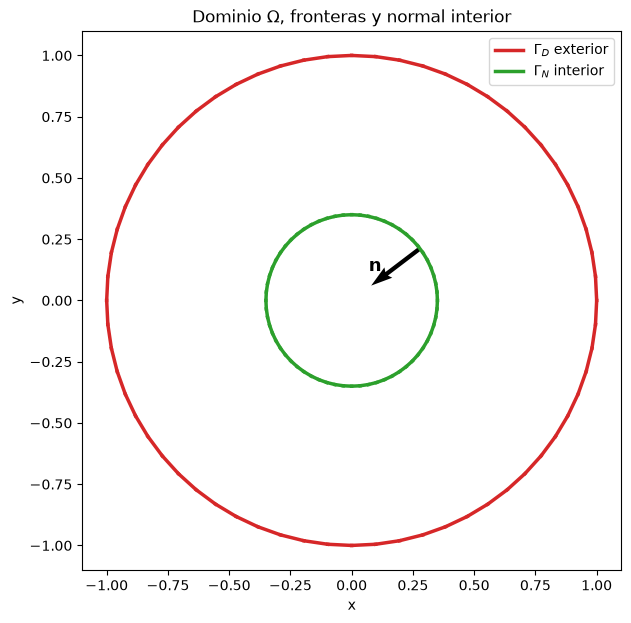

In [22]:
fig, ax = plt.subplots(figsize=(7, 7))
#mesh.draw(ax=ax, linewidth=0.45, color="0.55")

for boundary_name, color, label in [
    ("outer", "tab:red", r"$\Gamma_D$ exterior"),
    ("inner", "tab:green", r"$\Gamma_N$ interior"),
]:
    facets = mesh.facets[:, mesh.boundaries[boundary_name]]
    for number, edge in enumerate(facets.T):
        xy = mesh.p[:, edge]
        ax.plot(
            xy[0], xy[1], color=color, linewidth=2.5,
            label=label if number == 0 else None,
        )

# Normal exterior al dominio en un punto de la frontera interior.
theta_normal = 0.65
point_normal = R_INNER * np.array([np.cos(theta_normal), np.sin(theta_normal)])
normal_inner = -point_normal / np.linalg.norm(point_normal)
ax.quiver(
    point_normal[0], point_normal[1], normal_inner[0], normal_inner[1],
    angles="xy", scale_units="xy", scale=4.0, color="black", width=0.008,
)
ax.text(0.25 * point_normal[0], 0.55 * point_normal[1], r"$\mathbf{n}$", fontsize=13)

ax.set_title(r"Dominio $\Omega$, fronteras y normal interior")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal")
ax.legend(loc="upper right")
plt.show()

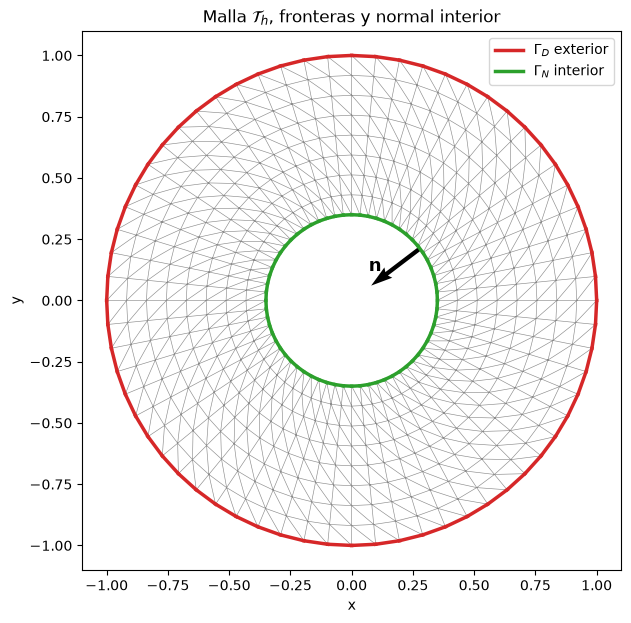

In [18]:
fig, ax = plt.subplots(figsize=(7, 7))
mesh.draw(ax=ax, linewidth=0.45, color="0.55")

for boundary_name, color, label in [
    ("outer", "tab:red", r"$\Gamma_D$ exterior"),
    ("inner", "tab:green", r"$\Gamma_N$ interior"),
]:
    facets = mesh.facets[:, mesh.boundaries[boundary_name]]
    for number, edge in enumerate(facets.T):
        xy = mesh.p[:, edge]
        ax.plot(
            xy[0], xy[1], color=color, linewidth=2.5,
            label=label if number == 0 else None,
        )

# Normal exterior al dominio en un punto de la frontera interior.
theta_normal = 0.65
point_normal = R_INNER * np.array([np.cos(theta_normal), np.sin(theta_normal)])
normal_inner = -point_normal / np.linalg.norm(point_normal)
ax.quiver(
    point_normal[0], point_normal[1], normal_inner[0], normal_inner[1],
    angles="xy", scale_units="xy", scale=4.0, color="black", width=0.008,
)
ax.text(0.25 * point_normal[0], 0.55 * point_normal[1], r"$\mathbf{n}$", fontsize=13)

ax.set_title(r"Malla $\mathcal{T}_h$, fronteras y normal interior")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal")
ax.legend(loc="upper right")
plt.show()

### Qué contiene una malla FEM

- `mesh.p`: coordenadas de los nodos;
- `mesh.t`: conectividad de los triángulos;
- `mesh.boundaries`: facetas asociadas a cada etiqueta de frontera.

La conectividad es esencial: FEM no utiliza solamente una nube de puntos, sino información sobre qué nodos forman cada elemento.

In [6]:
print("Forma de mesh.p:", mesh.p.shape)
print("Primeros cinco nodos:")
print(mesh.p[:, :5])
print()
print("Forma de mesh.t:", mesh.t.shape)
print("Primeros cinco triángulos:")
print(mesh.t[:, :5])

Forma de mesh.p: (2, 576)
Primeros cinco nodos:
[[0.35       0.34831465 0.34327485 0.33492912 0.32335784]
 [0.         0.034306   0.06828161 0.10159964 0.1339392 ]]

Forma de mesh.t: (3, 1024)
Primeros cinco triángulos:
[[ 0  0  1  1  2]
 [64  1 65  2 66]
 [65 65 66 66 67]]


# Parte III. Formulación débil

## 4. De la forma fuerte a la forma variacional

Partimos de

$$
\Delta u=f.
$$

Multiplicamos por una función test $v$ e integramos:

$$
\int_{\Omega}v\Delta u\,d\Omega
=
\int_{\Omega}fv\,d\Omega.
$$

Aplicando la identidad de Green:

$$
-\int_{\Omega}\nabla u\cdot\nabla v\,d\Omega
+
\int_{\partial\Omega}v\nabla u\cdot\mathbf{n}\,d\Gamma
=
\int_{\Omega}fv\,d\Omega.
$$

Las funciones test se anulan en $\Gamma_{D}$. En $\Gamma_{N}$ usamos

$$
\nabla u\cdot\mathbf{n}=h.
$$

Obtenemos

$$
\int_{\Omega}\nabla u\cdot\nabla v\,d\Omega
=
\int_{\Gamma_{N}}hv\,d\Gamma
-
\int_{\Omega}fv\,d\Omega.
$$

Es decir,

$$
a(u,v)=L(v),
$$

con

$$
a(u,v)=\int_{\Omega}\nabla u\cdot\nabla v\,d\Omega,
$$

$$
L(v)=\int_{\Gamma_{N}}hv\,d\Gamma-\int_{\Omega}fv\,d\Omega.
$$

> **Atención al signo:** al mantener $\Delta u=f$, el término volumétrico aparece con signo negativo en $L(v)$.

## 5. Neumann natural y Dirichlet esencial

### Neumann

El dato $h$ aparece directamente en $L(v)$ después de integrar por partes. Por eso se denomina condición **natural**.

### Dirichlet

El dato

$$
u=g
\qquad\text{en }\Gamma_{D}
$$

no aparece como un término adicional en $L(v)$. Debemos buscar la solución en

$$
V_{g}
=
\left\{
w\in H^{1}(\Omega):w=g\text{ en }\Gamma_{D}
\right\},
$$

mientras que las funciones test pertenecen a

$$
V_{0}
=
\left\{
v\in H^{1}(\Omega):v=0\text{ en }\Gamma_{D}
\right\}.
$$

En el cálculo discreto impondremos los valores de $g$ en los grados de libertad de $\Gamma_{D}$ y condensaremos el sistema.

> Esta diferencia entre condiciones naturales y esenciales reaparecerá en la sesión sobre PINNs.

# Parte IV. Elementos finitos

## 6. Espacio discreto $P_{1}$

Sustituimos el espacio infinito por un espacio finito:

$$
V_{h}=\operatorname{span}\{\varphi_{1},\ldots,\varphi_{N}\}.
$$

La aproximación es

$$
u_{h}=\sum_{j=1}^{N}U_{j}\varphi_{j}.
$$

Para elementos triangulares $P_{1}$:

- cada función es lineal dentro de cada triángulo;
- los grados de libertad son valores nodales;
- la función global es continua;
- cada función de base tiene soporte local.

El soporte local explica por qué la matriz FEM será dispersa.

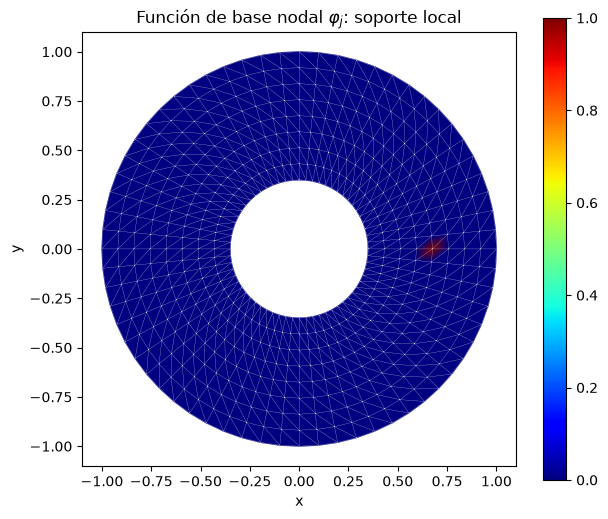

In [7]:
# Visualizamos una función de base global asociada a un nodo interior.
radius_nodes = np.sqrt(mesh.p[0] ** 2 + mesh.p[1] ** 2)
target = 0.5 * (R_INNER + R_OUTER)
central_dof = np.argmin((radius_nodes - target) ** 2 + 0.05 * mesh.p[1] ** 2)

phi = np.zeros(basis.N)
phi[central_dof] = 1.0

fig, ax = plt.subplots(figsize=(7, 6))
mesh.plot(phi, ax=ax, shading="gouraud", colorbar=True)
mesh.draw(ax=ax, linewidth=0.15, color="white")
ax.set_title(r"Función de base nodal $\varphi_j$: soporte local")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal")
plt.show()

## 7. Del problema variacional a $A\mathbf{U}=\mathbf{b}$

Sustituimos

$$
u_{h}=\sum_{j=1}^{N}U_{j}\varphi_{j}
$$

y probamos con cada $\varphi_{i}$. El resultado es

$$
A\mathbf{U}=\mathbf{b},
$$

con

$$
A_{ij}
=
\int_{\Omega}
\nabla\varphi_{j}\cdot\nabla\varphi_{i}\,d\Omega,
$$

$$
b_{i}
=
\int_{\Gamma_{N}}h\varphi_{i}\,d\Gamma
-
\int_{\Omega}f\varphi_{i}\,d\Omega.
$$

`scikit-fem` ensambla estas contribuciones sobre todos los elementos y facetas de Neumann.

In [8]:
@BilinearForm
def bilinear_form(u, v, w):
    return dot(grad(u), grad(v))


@LinearForm
def volume_load(v, w):
    return -source_term(w.x[0], w.x[1]) * v


@LinearForm
def neumann_load(v, w):
    return neumann_data(w.x[0], w.x[1]) * v


A = asm(bilinear_form, basis)
b_volume = asm(volume_load, basis)

inner_basis = FacetBasis(
    mesh,
    ElementTriP1(),
    facets=mesh.boundaries["inner"],
)
b_neumann = asm(neumann_load, inner_basis)
b = b_volume + b_neumann

print("Dimensión de A:", A.shape)
print("Entradas no nulas:", A.nnz)
print(f"Fracción de entradas no nulas: {A.nnz / (A.shape[0] * A.shape[1]):.3%}")
print(f"Norma del término volumétrico: {np.linalg.norm(b_volume):.6e}")
print(f"Norma del término de Neumann:  {np.linalg.norm(b_neumann):.6e}")

Dimensión de A: (576, 576)
Entradas no nulas: 3776
Fracción de entradas no nulas: 1.138%
Norma del término volumétrico: 6.677066e-02
Norma del término de Neumann:  2.830555e-01


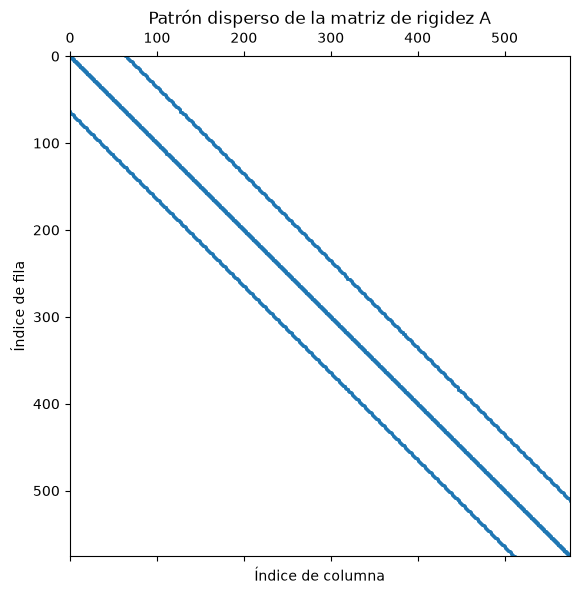

In [9]:
fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.spy(A, markersize=1.0)
ax.set_title("Patrón disperso de la matriz de rigidez A")
ax.set_xlabel("Índice de columna")
ax.set_ylabel("Índice de fila")
plt.show()

## 8. Imposición de Dirichlet no homogénea

Para cada grado de libertad de $\Gamma_{D}$ prescribimos

$$
U_{j}=g(\mathbf{x}_{j}).
$$

La condensación elimina esas incógnitas conocidas y modifica el segundo miembro del sistema reducido. No calculamos $A^{-1}$ explícitamente: resolvemos el sistema lineal.

In [10]:
dirichlet_dofs = basis.get_dofs("outer")
dirichlet_indices = dirichlet_dofs.all()

prescribed_values = np.zeros(basis.N)
xy_dirichlet = mesh.p[:, dirichlet_indices]
prescribed_values[dirichlet_indices] = dirichlet_data(
    xy_dirichlet[0], xy_dirichlet[1]
)

u_h = solve(*condense(
    A,
    b,
    x=prescribed_values,
    D=dirichlet_dofs,
))

print(f"Grados de libertad de Dirichlet: {len(dirichlet_indices)}")
print(f"min(u_h) = {u_h.min():.6f}")
print(f"max(u_h) = {u_h.max():.6f}")

Grados de libertad de Dirichlet: 64
min(u_h) = -0.995965
max(u_h) = 0.995965


# Parte V. Resultados y validación

## 9. Visualización de la solución

Los coeficientes de $u_{h}$ son los valores nodales de la aproximación $P_{1}$. Dentro de cada triángulo se interpola linealmente.

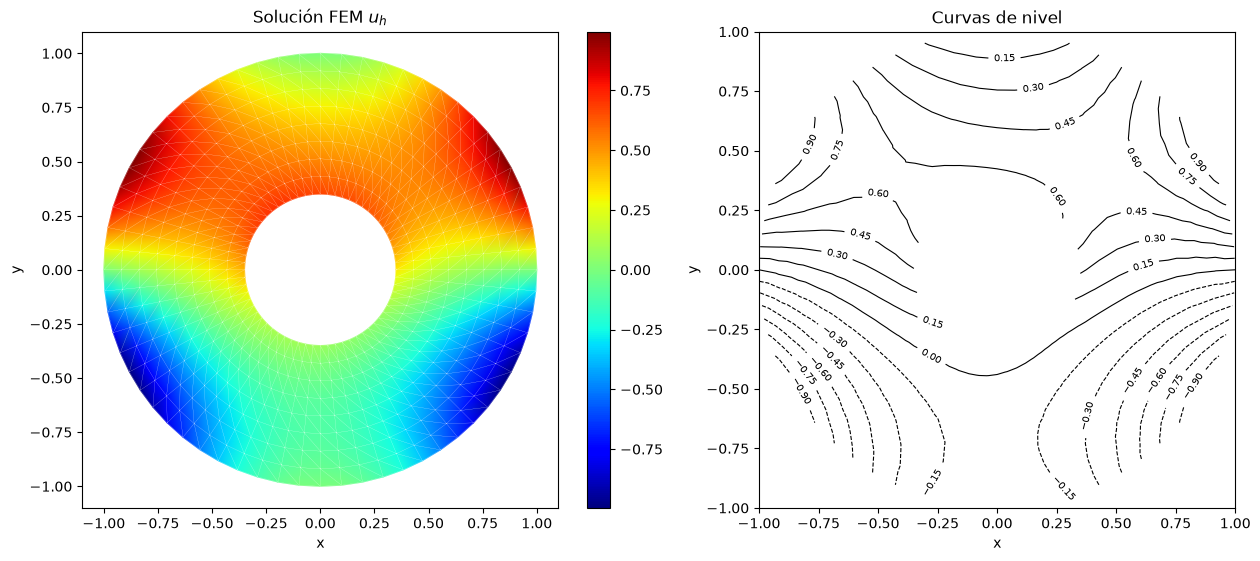

In [11]:
triangulation = Triangulation(mesh.p[0], mesh.p[1], mesh.t.T)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), constrained_layout=True)
mesh.plot(u_h, ax=axes[0], shading="gouraud", colorbar=True)
mesh.draw(ax=axes[0], linewidth=0.12, color="white")
axes[0].set_title(r"Solución FEM $u_h$")

contours = axes[1].tricontour(
    triangulation, u_h, levels=18, colors="black", linewidths=0.8
)
axes[1].clabel(contours, inline=True, fontsize=7)
axes[1].set_title("Curvas de nivel")

for ax in axes:
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal")
plt.show()

## 10. Primera comprobación: condición de Dirichlet

Comprobamos de forma independiente que los valores nodales de la frontera exterior coinciden con $g$. Esta prueba no valida todo el cálculo, pero puede detectar una frontera mal etiquetada o una imposición incorrecta.

In [12]:
dirichlet_defect = u_h[dirichlet_indices] - dirichlet_data(
    xy_dirichlet[0], xy_dirichlet[1]
)
print(f"Defecto máximo de Dirichlet: {np.max(np.abs(dirichlet_defect)):.6e}")
assert np.max(np.abs(dirichlet_defect)) < 1.0e-11

Defecto máximo de Dirichlet: 0.000000e+00


## 11. Residuo fuerte y estimador residual

Con la convención

$$
\Delta u=f,
$$

el residual fuerte es

$$
R_{K}=\Delta u_{h}-f.
$$

Para $P_{1}$, $u_{h}$ es lineal en cada triángulo y

$$
\Delta u_{h}|_{K}=0.
$$

Por ello, la norma no escalada del residual fuerte no es por sí sola un estimador adecuado. Un indicador residual conforme combina:

$$
\eta^{2}
=
\sum_{K}h_{K}^{2}\|\Delta u_{h}-f\|_{L^{2}(K)}^{2}
+
\sum_{E\in\mathcal{E}_{h}^{\mathrm{int}}}h_{E}
\left\|[\![\nabla u_{h}\cdot\mathbf{n}_{E}]\!]\right\|_{L^{2}(E)}^{2}
+
\sum_{E\subset\Gamma_{N}}h_{E}
\|h-\nabla u_{h}\cdot\mathbf{n}\|_{L^{2}(E)}^{2}.
$$

La implementación siguiente es pedagógica. Usa valores en centroides y puntos medios. Para cálculo certificado habría que cuidar cuadratura, constantes, geometría curva y oscilación de los datos.

In [13]:
def residual_estimator_p1(mesh, u_h, r_inner=R_INNER):
    points = mesh.p.T
    triangles = mesh.t.T
    n_elements = len(triangles)

    gradients = np.zeros((n_elements, 2))
    areas = np.zeros(n_elements)
    diameters = np.zeros(n_elements)
    centroids = np.zeros((n_elements, 2))

    for element, vertices in enumerate(triangles):
        coordinates = points[vertices]
        centroids[element] = coordinates.mean(axis=0)
        edge_lengths = [
            np.linalg.norm(coordinates[(i + 1) % 3] - coordinates[i])
            for i in range(3)
        ]
        diameters[element] = max(edge_lengths)
        jacobian = np.column_stack((
            coordinates[1] - coordinates[0],
            coordinates[2] - coordinates[0],
        ))
        areas[element] = 0.5 * abs(np.linalg.det(jacobian))

        interpolation_matrix = np.column_stack((
            np.ones(3), coordinates[:, 0], coordinates[:, 1]
        ))
        coefficients = np.linalg.solve(
            interpolation_matrix, u_h[vertices]
        )
        gradients[element] = coefficients[1:]

    # Para P1, Delta u_h = 0 en el interior de cada elemento.
    residual_centroid = -source_term(centroids[:, 0], centroids[:, 1])
    element_terms = diameters**2 * residual_centroid**2 * areas
    local_eta_squared = element_terms.copy()

    edge_to_elements = {}
    for element, vertices in enumerate(triangles):
        for local_a, local_b in [(0, 1), (1, 2), (2, 0)]:
            key = tuple(sorted((vertices[local_a], vertices[local_b])))
            edge_to_elements.setdefault(key, []).append(element)

    jump_total = 0.0
    neumann_total = 0.0

    for (vertex_a, vertex_b), adjacent in edge_to_elements.items():
        point_a = points[vertex_a]
        point_b = points[vertex_b]
        edge_vector = point_b - point_a
        edge_length = np.linalg.norm(edge_vector)
        midpoint = 0.5 * (point_a + point_b)

        if len(adjacent) == 2:
            left, right = adjacent
            normal = np.array([edge_vector[1], -edge_vector[0]]) / edge_length
            flux_jump = np.dot(gradients[left] - gradients[right], normal)
            contribution = edge_length**2 * flux_jump**2
            jump_total += contribution
            local_eta_squared[left] += 0.5 * contribution
            local_eta_squared[right] += 0.5 * contribution

        elif len(adjacent) == 1:
            radius = np.linalg.norm(midpoint)
            if abs(radius - r_inner) < 0.08:
                element = adjacent[0]
                outward_normal = -midpoint / radius
                numerical_flux = np.dot(gradients[element], outward_normal)
                prescribed_flux = neumann_data(midpoint[0], midpoint[1])
                boundary_residual = prescribed_flux - numerical_flux
                contribution = edge_length**2 * boundary_residual**2
                neumann_total += contribution
                local_eta_squared[element] += contribution

    strong_residual_l2 = np.sqrt(np.sum(residual_centroid**2 * areas))
    estimator = np.sqrt(np.sum(element_terms) + jump_total + neumann_total)

    return {
        "strong_residual_l2": strong_residual_l2,
        "estimator": estimator,
        "local": np.sqrt(local_eta_squared),
        "element_part": np.sqrt(np.sum(element_terms)),
        "jump_part": np.sqrt(jump_total),
        "neumann_part": np.sqrt(neumann_total),
    }


indicator = residual_estimator_p1(mesh, u_h)
for key in [
    "strong_residual_l2",
    "estimator",
    "element_part",
    "jump_part",
    "neumann_part",
]:
    print(f"{key:22s}: {indicator[key]:.6e}")

strong_residual_l2    : 8.776175e-01
estimator             : 8.609337e-01
element_part          : 1.002773e-01
jump_part             : 8.537879e-01
neumann_part          : 4.687824e-02


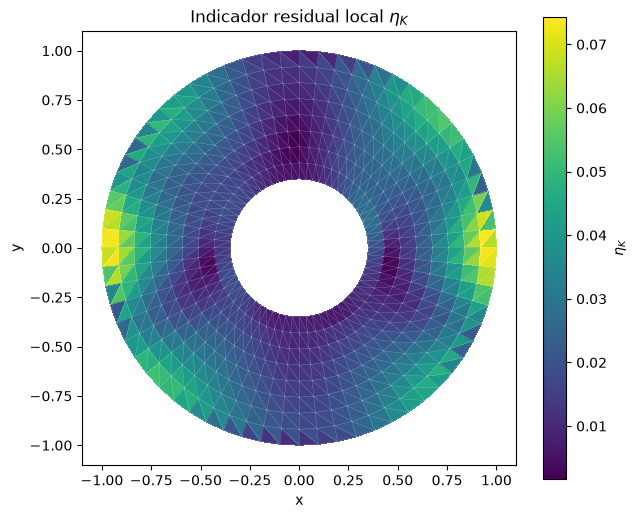

In [14]:
fig, ax = plt.subplots(figsize=(7, 6))
image = ax.tripcolor(
    triangulation,
    facecolors=indicator["local"],
    shading="flat",
)
mesh.draw(ax=ax, linewidth=0.10, color="white")
ax.set_title(r"Indicador residual local $\eta_K$")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal")
fig.colorbar(image, ax=ax, label=r"$\eta_K$")
plt.show()

## 12. Estudio de refinamiento

Como no conocemos una solución analítica para los datos elegidos, no llamaremos “error exacto” a ninguna cantidad. Compararemos:

1. la norma del residual fuerte sin escalar;
2. el estimador residual completo $\eta$;
3. la solución en un conjunto de puntos compartidos con la malla más fina.

La tercera cantidad es una **diferencia respecto a una solución de referencia**, no un error exacto.

In [15]:
def solve_annulus(n_radial, n_angular):
    current_mesh = make_annulus_mesh(
        n_radial=n_radial,
        n_angular=n_angular,
    )
    current_basis = Basis(current_mesh, ElementTriP1())
    current_A = asm(bilinear_form, current_basis)
    current_b = asm(volume_load, current_basis)

    current_inner_basis = FacetBasis(
        current_mesh,
        ElementTriP1(),
        facets=current_mesh.boundaries["inner"],
    )
    current_b += asm(neumann_load, current_inner_basis)

    current_D = current_basis.get_dofs("outer")
    current_indices = current_D.all()
    current_values = np.zeros(current_basis.N)
    current_xy = current_mesh.p[:, current_indices]
    current_values[current_indices] = dirichlet_data(
        current_xy[0], current_xy[1]
    )

    current_solution = solve(*condense(
        current_A,
        current_b,
        x=current_values,
        D=current_D,
    ))
    current_indicator = residual_estimator_p1(
        current_mesh, current_solution
    )

    return {
        "mesh": current_mesh,
        "basis": current_basis,
        "solution": current_solution,
        "dofs": current_basis.N,
        "strong": current_indicator["strong_residual_l2"],
        "eta": current_indicator["estimator"],
    }


# Las mallas están anidadas en sus coordenadas polares: 4/32, 8/64 y 16/128.
refinement_specs = [(4, 32), (8, 64), (16, 128)]
refinement_results = [solve_annulus(nr, nt) for nr, nt in refinement_specs]

reference = refinement_results[-1]
reference_lookup = {
    (round(x, 12), round(y, 12)): value
    for x, y, value in zip(
        reference["mesh"].p[0],
        reference["mesh"].p[1],
        reference["solution"],
    )
}

for result in refinement_results:
    differences = []
    for x, y, value in zip(
        result["mesh"].p[0],
        result["mesh"].p[1],
        result["solution"],
    ):
        reference_value = reference_lookup[(round(x, 12), round(y, 12))]
        differences.append(value - reference_value)
    result["reference_nodal_rms"] = np.sqrt(np.mean(np.asarray(differences) ** 2))

print(f"{'Nr':>4} {'Ntheta':>8} {'dofs':>8} {'residuo fuerte':>18} {'eta':>14} {'dif. ref. RMS':>16}")
for (nr, nt), result in zip(refinement_specs, refinement_results):
    print(
        f"{nr:4d} {nt:8d} {result['dofs']:8d} "
        f"{result['strong']:18.6e} {result['eta']:14.6e} "
        f"{result['reference_nodal_rms']:16.6e}"
    )

Transforming over 1000 elements to C_CONTIGUOUS.
Transforming over 1000 vertices to C_CONTIGUOUS.
Transforming over 1000 elements to C_CONTIGUOUS.


  Nr   Ntheta     dofs     residuo fuerte            eta    dif. ref. RMS
   4       32      160       8.718243e-01   1.612640e+00     4.278839e-03
   8       64      576       8.776175e-01   8.609337e-01     8.328484e-04
  16      128     2176       8.790684e-01   4.415086e-01     0.000000e+00


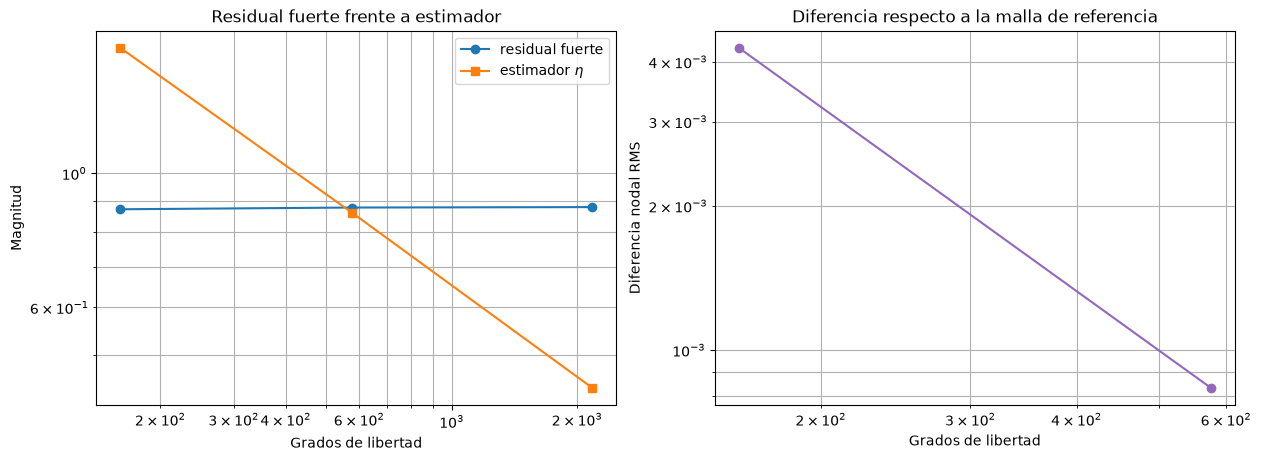

In [16]:
dofs = np.array([result["dofs"] for result in refinement_results])
strong_values = np.array([result["strong"] for result in refinement_results])
eta_values = np.array([result["eta"] for result in refinement_results])
reference_differences = np.array([
    result["reference_nodal_rms"] for result in refinement_results
])

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5), constrained_layout=True)
axes[0].loglog(dofs, strong_values, "o-", label="residual fuerte")
axes[0].loglog(dofs, eta_values, "s-", label=r"estimador $\eta$")
axes[0].set_xlabel("Grados de libertad")
axes[0].set_ylabel("Magnitud")
axes[0].set_title("Residual fuerte frente a estimador")
axes[0].grid(True, which="both")
axes[0].legend()

# Se omite el último valor, que es cero por ser la propia referencia.
axes[1].loglog(
    dofs[:-1], reference_differences[:-1], "o-", color="tab:purple"
)
axes[1].set_xlabel("Grados de libertad")
axes[1].set_ylabel("Diferencia nodal RMS")
axes[1].set_title("Diferencia respecto a la malla de referencia")
axes[1].grid(True, which="both")
plt.show()

### Interpretación correcta

Debemos distinguir:

#### Error verdadero

$$
\|u-u_{h}\|,
$$

que requiere conocer la solución exacta $u$.

#### Diferencia respecto a una referencia

$$
\|u_{\mathrm{ref}}-u_{h}\|,
$$

que depende de la calidad de $u_{\mathrm{ref}}$.

#### Estimador a posteriori

$$
\eta(u_{h},f,g,h,\mathcal{T}_{h}),
$$

que se calcula usando datos conocidos y la solución discreta.

El residual fuerte sin escalar permanece aproximadamente constante para elementos $P_{1}$. El estimador completo disminuye porque incorpora el tamaño de malla, los saltos de flujo y el defecto de Neumann.

# Parte VI. La misma idea en 1D, 2D y 3D

La secuencia matemática es esencialmente la misma:

$$
\text{forma fuerte}
\longrightarrow
\text{forma débil}
\longrightarrow
V_{h}
\longrightarrow
A\mathbf{U}=\mathbf{b}.
$$

Lo que cambia es la geometría y el coste computacional:

- **1D:** intervalos divididos en segmentos;
- **2D:** dominios divididos en triángulos o cuadriláteros;
- **3D:** volúmenes divididos en tetraedros o hexaedros.

La complejidad de generar la malla, almacenar la matriz y resolver el sistema crece de forma importante con la dimensión.

# Conclusiones

En este cuaderno hemos recorrido:

$$
(\Omega,f,g,h)
\longrightarrow
\text{forma débil}
\longrightarrow
(\mathcal{T}_{h},V_{h})
\longrightarrow
A\mathbf{U}=\mathbf{b}
\longrightarrow
u_{h}
\longrightarrow
\text{validación}.
$$

Puntos clave:

- la malla aproxima la geometría y almacena conectividad;
- la formulación débil reduce el orden de derivación requerido;
- Neumann aparece como condición natural;
- Dirichlet restringe el espacio y se impone algebraicamente;
- los elementos $P_{1}$ construyen una función continua y lineal por triángulos;
- el soporte local produce una matriz dispersa;
- resolver no equivale a validar;
- sin solución exacta debemos hablar de referencia o de estimadores, no de error exacto.

## Puente con la sesión 2

FEM representa la solución mediante

$$
u_{h}=\sum_{j=1}^{N}U_{j}\varphi_{j}.
$$

En la segunda sesión utilizaremos otra familia de funciones:

$$
u_{\theta}(x,y)=\operatorname{NN}_{\theta}(x,y).
$$

La pregunta matemática seguirá siendo la misma:

> ¿Cómo representamos y aproximamos una función que satisface una EDP y sus condiciones de contorno?

## Preguntas para discusión

1. ¿Qué cambiaría si intercambiáramos $\Gamma_{D}$ y $\Gamma_{N}$?
2. ¿Por qué la normal del agujero apunta hacia el centro?
3. ¿Qué información se perdería si conserváramos solamente los nodos pero no la conectividad?
4. ¿Por qué el residual fuerte no basta para validar una solución $P_{1}$?
5. ¿Qué coste tiene refinar uniformemente toda la malla?
6. ¿Qué partes del flujo cambiarían al pasar a una geometría 3D?

## Material complementario previsto

- notebook de ejercicios FEM sin soluciones;
- versión profesional del mismo problema con FEniCSx y Gmsh;
- notebook de la sesión 2 sobre redes neuronales y PINNs.